<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/SupportVectorMachine_Ansh_CS23185.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
path="/content/drive/MyDrive/ML/BreastCancer.csv"
data=pd.read_csv(path)

In [4]:
print(data.head())
print(data.shape)
print(data.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [5]:
data = data.drop(['id', 'Unnamed: 32'], axis=1)

In [6]:
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

In [7]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

In [12]:
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:

    print("\n==============================")
    print(f"SVM Kernel: {kernel.upper()}")
    print("==============================")

    for split in [0.2, 0.3]:

        print(f"\nSplit: {int((1-split)*100)}-{int(split*100)}")

        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=split, random_state=42
        )

        # Scaling (IMPORTANT for SVM)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Model
        svm_model = SVC(kernel=kernel, probability=True)
        svm_model.fit(X_train, y_train)

        # Prediction
        y_pred = svm_model.predict(X_test)

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        print("Accuracy:", acc)


SVM Kernel: LINEAR

Split: 80-20
Accuracy: 0.956140350877193

Split: 70-30
Accuracy: 0.9766081871345029

SVM Kernel: RBF

Split: 80-20
Accuracy: 0.9824561403508771

Split: 70-30
Accuracy: 0.9766081871345029

SVM Kernel: POLY

Split: 80-20
Accuracy: 0.868421052631579

Split: 70-30
Accuracy: 0.8947368421052632


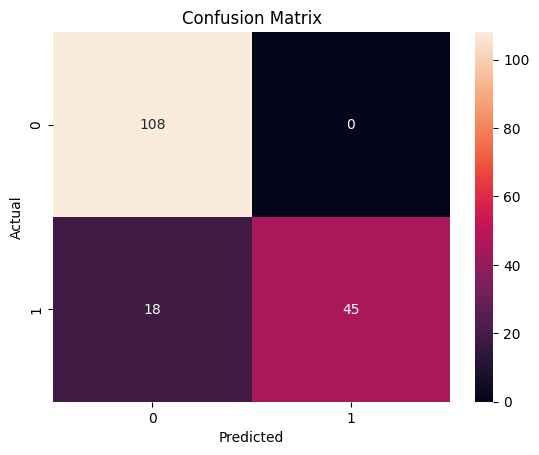

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

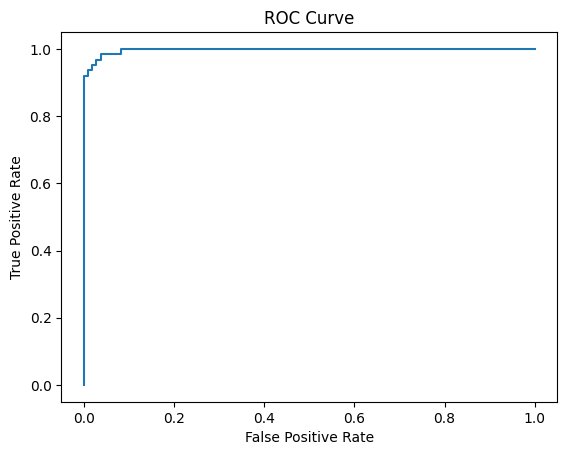

In [13]:
from sklearn.metrics import roc_curve, auc

y_prob = svm_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()